In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from specula.mmlib.utils import get_pupil_mask, shift_image, get_frame_pupil_centers, two_level_thresholding


2026-08-19 10:34:57,739 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-19 10:34:57,861 [INFO]: [specula]: Default device is GPU number 0


In [2]:
def get_meas_frame(im,idx=None,trim:bool=True):
    imstd = np.std(im,axis=1).reshape([240,240])
    ref_centers = get_frame_pupil_centers(imstd)
    savg_center = np.mean(ref_centers,axis=0)
    hsize = 120
    if idx is None:
        imframe = imstd
    else:
        imframe = im[:,idx].reshape([240,240])
    frimg = shift_image(imframe, shift=hsize-savg_center[1], axis=0)
    frimg = shift_image(frimg, shift=hsize-savg_center[0], axis=1)
    if trim:
        return frimg[60:180,60:180]
    else:
        return frimg

def get_sim_frame(im,idx,pupids):
    npix = 240
    fimg_bench = np.zeros([npix,npix])
    rtot = 0
    for k in range(4):
        valid_ids = pupids[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_bench, pupids[valid_ids,k], im[rtot:rtot+len_ids,idx])
        rtot += len_ids
    bench2d = fimg_bench.reshape([npix,npix])
    return bench2d[60:180,60:180]

[[1.12671629 1.15460141 1.12255645 1.15876126]
 [1.03010862 0.97960297 0.88440624 0.93491189]]
[[ 85.2145046   87.07150153]
 [ 86.30064888 141.65104542]
 [154.61538462  85.73076923]
 [153.77883096 146.0221169 ]]


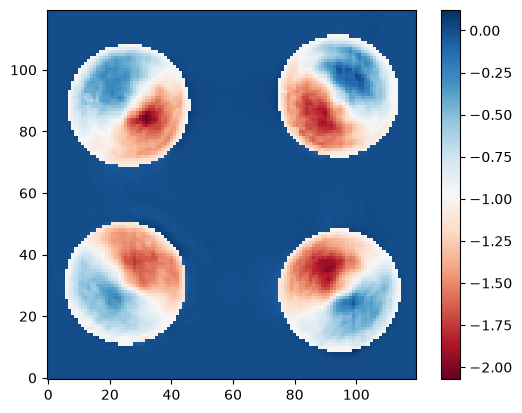

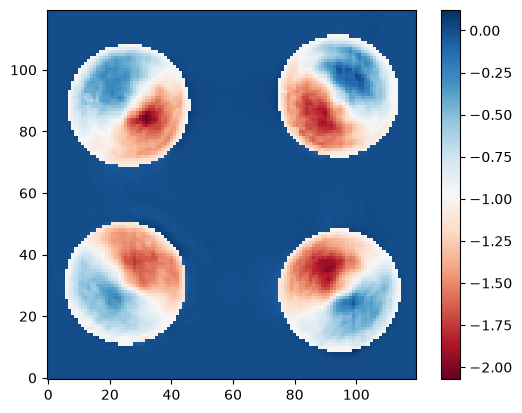

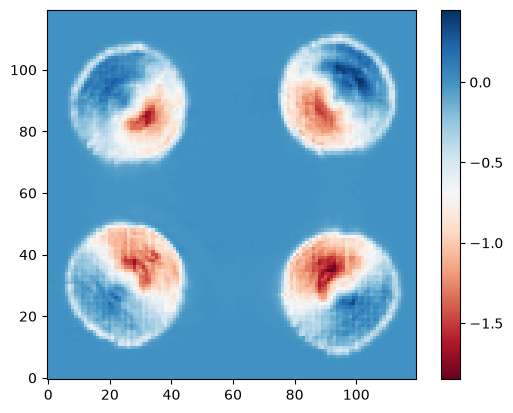

In [3]:
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')[60:180,60:180]
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')[60:180,60:180]
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260815_194918.fits') #194038 #193320
rec = np.linalg.pinv(im)

stdimg = get_meas_frame(im,trim=False)
frimg = get_meas_frame(im,idx=3)

ref_centers = get_frame_pupil_centers(stdimg)
avg_center = np.mean(ref_centers,axis=0)
ref_dcenters = ref_centers-avg_center

# pupids = np.array([0,1,2,3],dtype=int)
# pyrids = np.array([2,3,1,0],dtype=int)
pupids = np.array([3,2,1,0],dtype=int)
pyrids = np.array([0,1,2,3],dtype=int)
print(abs(ref_dcenters[pupids].T/30))
print(ref_centers)

plt.figure()
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()

img = np.load('/raid1/mmenessini/calibration/EKARUS/data/OnBench_frame.npy')
ref_centers = get_frame_pupil_centers(img)
savg_center = np.mean(ref_centers,axis=0)
hsize=120
img = shift_image(img, shift=hsize-savg_center[1], axis=0)
img = shift_image(img, shift=hsize-savg_center[0], axis=1)
img = img[60:180,60:180]

plt.figure()
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()


plt.figure()
plt.imshow(frimg/np.max(frimg)-img/np.max(img),origin='lower',cmap='RdBu')
plt.colorbar()

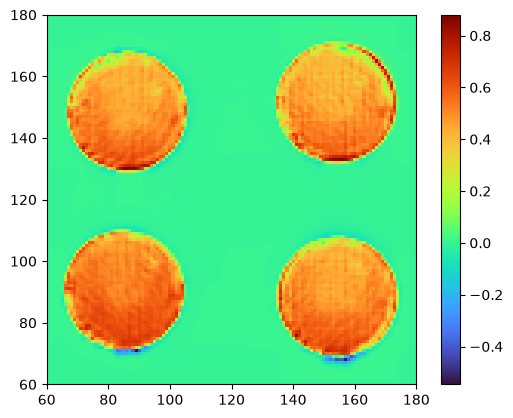

In [ ]:
# frame = fits.getdata('/raid1/mmenessini/results/EKARUS/frame.fits')[0]

# plt.figure()
# plt.imshow(frame/np.max(frame)-stdimg/np.max(stdimg),origin='lower',cmap='turbo')
# plt.xlim([60,180])
# plt.ylim([60,180])
# plt.colorbar()

In [5]:
rMod = 5
# benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_measIF_dm468_im.fits')
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_dm468_onbench_synim.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids_bench = pup_hdu[1].data
benchrec = np.linalg.pinv(benchim)

Text(0.5, 1.0, 'Difference')

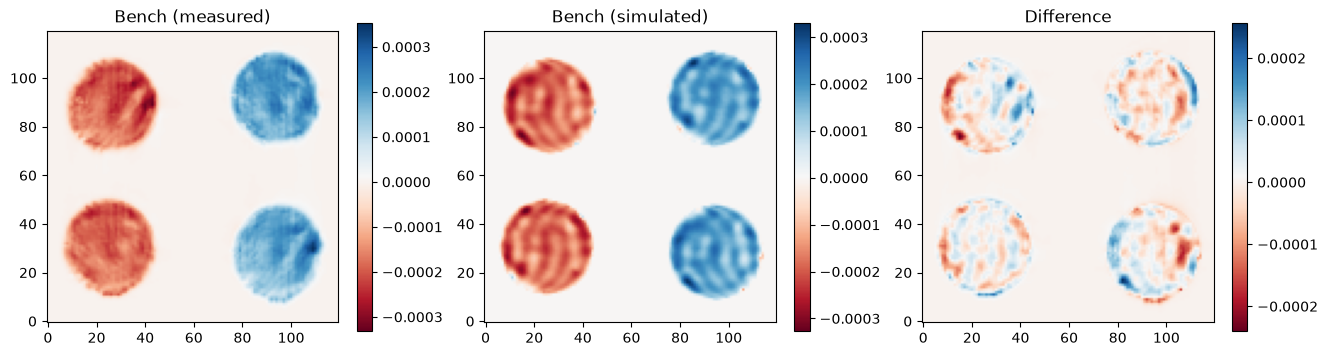

In [6]:
jdx = 0

f2d_meas = get_meas_frame(im,idx=jdx)
f2d_bench = get_sim_frame(benchim,idx=jdx,pupids=pup_ids_bench)

f2d_bench *= np.std(f2d_meas[pyr_mask])/np.std(f2d_bench[pyr_mask])

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(f2d_meas,origin='lower',cmap='RdBu')
# plt.imshow(np.ma.masked_array(f2d_meas,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Bench (measured)')
plt.subplot(1,3,2)
plt.imshow(f2d_bench,origin='lower',cmap='RdBu')
# plt.imshow(np.ma.masked_array(f2d_bench,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Bench (simulated)')
plt.subplot(1,3,3)
plt.imshow(f2d_bench-f2d_meas,origin='lower',cmap='RdBu')
# plt.imshow(np.ma.masked_array(f2d_bench-f2d_meas,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Difference')

4671 4662


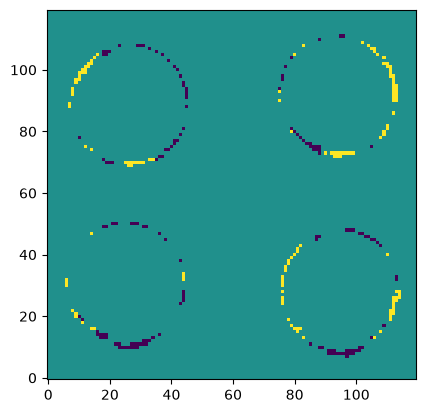

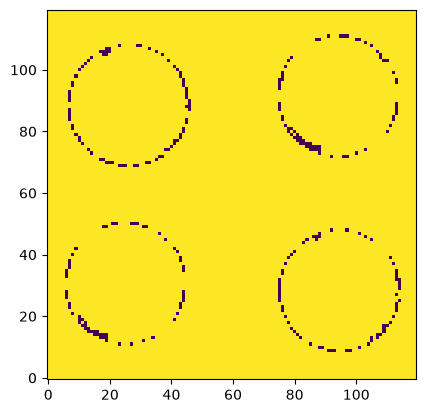

In [7]:
meas_mask = two_level_thresholding(abs(f2d_meas))
sym_mask = two_level_thresholding(abs(f2d_bench))

print(np.sum(meas_mask),np.sum(sym_mask))

plt.figure()
plt.imshow(sym_mask.astype(float)-meas_mask.astype(float),origin='lower')
plt.figure()
plt.imshow(sym_mask.astype(float)-pyr_mask.astype(float),origin='lower')

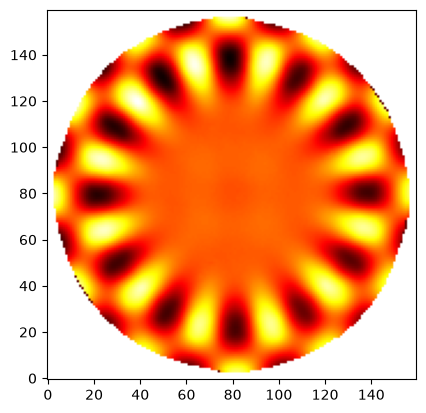

In [8]:
frames = fits.getdata('/raid1/mmenessini/results/EKARUS/dm_ef.fits')[:,1,:,:]
amps = fits.getdata('/raid1/mmenessini/results/EKARUS/dm_ef.fits')[:,0,:,:]
ekapup = fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/DM468_160pixels_shift.fits')

idx = 100
plt.figure()
plt.imshow(np.ma.masked_array(frames[idx*2],mask=(1-ekapup).astype(bool)),origin='lower',cmap='hot')